# ACCELERATION (Second Derivatives)

## $ A_n = \frac{d_{Vn}}{d_t} => $

## $ A_n = \frac{y_{n+1} - 2y_{n} + y_{n-1}}{d_t ^2}$

In [2]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [3]:
def acceleration(audio, sr):

    dt = 1/sr

    a = np.zeros_like(audio)

    a[1:-1] = (audio[2:] - 2* audio[1:-1] + audio[:-2])/(dt ** 2)
    a[0] = a[1]
    a[-1] = a[-2]

    return a

In [4]:
sr = 8000

file = 'test_healthy_voice.wav'

audio, sr = librosa.load(file, sr=sr, mono=True)
audio

array([ 0.01015559,  0.09465139,  0.18256481, ..., -0.22696644,
       -0.13908541, -0.04302341], dtype=float32)

In [6]:
a = acceleration(audio, sr)

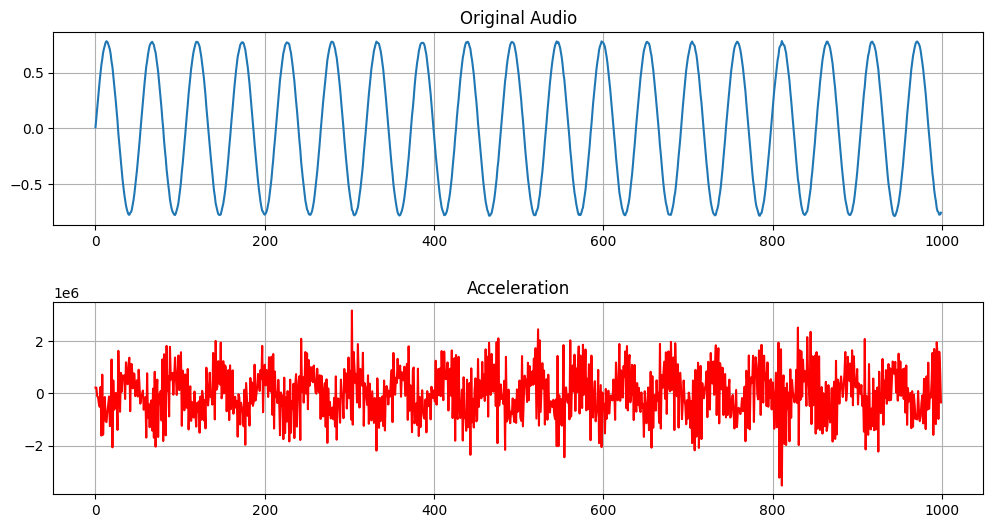

In [7]:
plt.figure(figsize=(12,6))
plt.subplot(211)
plt.plot(audio[:1000])
plt.title("Original Audio")
plt.grid(True)


plt.subplot(212)
plt.plot(a[:1000], color='red')
plt.title("Acceleration")
plt.grid(True)




plt.subplots_adjust(hspace=0.4)
plt.show()

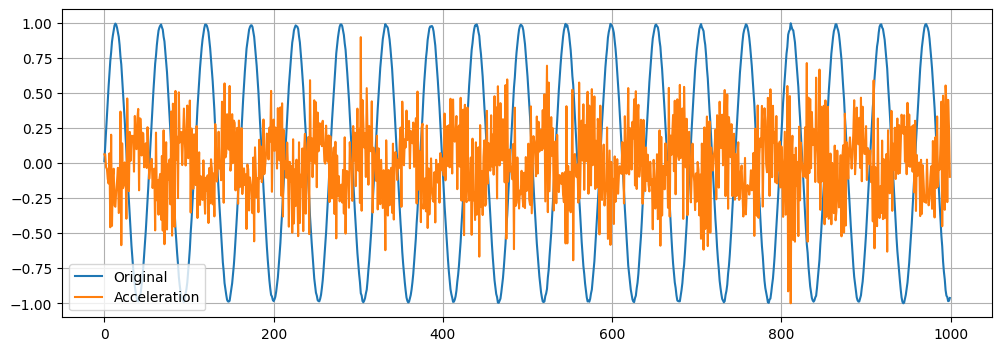

In [9]:
audio_norm = audio[:1000]/np.max(np.abs(audio[:1000]))
a_norm= a[:1000]/np.max(np.abs(a[:1000]))

plt.figure(figsize=(12, 4))
plt.plot(audio_norm[:1000], label='Original')
plt.plot(a_norm[:1000], label='Acceleration')
plt.legend()
plt.grid(True)
plt.show()